# Experiment 4: Large Dataset Lexical Baseline

Simple supervised baseline on the same large customer-support dataset used in Experiment 3.

## Hypothesis

TF-IDF Logistic Regression should be a strong baseline because many operational labels are tied to explicit ticket wording.  
Words such as `outage`, `billing`, `security`, `request`, and `incident` are expected to map strongly to `priority`, `type`, and `tag_1`.

## Pipeline

**load data -> define tasks -> stratified splits -> TF-IDF + Logistic Regression -> evaluation**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

## 1. Data

`large_dataset_preprocessed.csv`, same source used by Experiment 3 for large-dataset priority/tag experiments.

In [2]:
ROOT = Path.cwd().parents[2]
DATA = ROOT / 'data' / 'processed' / 'large_dataset_preprocessed.csv'
OUT_DIR = ROOT / 'results' / 'Experiment_4_5_LargeDataset'
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42

df = pd.read_csv(DATA).dropna(subset=['text_cleaned']).copy()
df['row_id'] = np.arange(len(df))
df['text_cleaned'] = df['text_cleaned'].astype(str).str.replace(r'\s+', ' ', regex=True).str.strip()

print(f'Large dataset rows: {len(df)}')
df[['text_cleaned', 'priority', 'type', 'tag_1', 'tag_2']].head(3)

Large dataset rows: 28243


,text_cleaned,priority,type,tag_1,tag_2
0,"Account Disruption Dear Customer Support Team,...",high,Incident,Account,Disruption
1,Query About Smart Home System Integration Feat...,medium,Request,Product,Feature
2,Inquiry Regarding Invoice Details Dear Custome...,low,Request,Billing,Payment


## 2. Task Design

Three supervised tasks:

- `priority`: same label target as Experiment 3b (`high`, `medium`, `low`).
- `type`: ticket workflow type (`Incident`, `Request`, `Problem`, `Change`).
- `tag_1_top8`: the eight most frequent primary issue tags, used as a high-signal issue-category task.

`tag_1_top8` is not a direct replacement for Experiment 3a's Top-2 multi-label task, but it tests whether the same corpus supports a simpler and more reliable issue-labelling setup.

In [3]:
# Build comparable single-label tasks from the same cleaned ticket text.
def make_task_frame(df, task_name):
    if task_name == 'priority':
        frame = df[df['priority'].isin(['high', 'medium', 'low'])].copy()
        frame['label'] = frame['priority']
    elif task_name == 'type':
        frame = df.dropna(subset=['type']).copy()
        frame['label'] = frame['type']
    elif task_name == 'tag_1_top8':
        top_tags = df['tag_1'].value_counts().head(8).index.tolist()
        frame = df[df['tag_1'].isin(top_tags)].copy()
        frame['label'] = frame['tag_1']
    else:
        raise ValueError(task_name)

    return frame[['row_id', 'text_cleaned', 'label']].reset_index(drop=True)

tasks = ['priority', 'type', 'tag_1_top8']

task_data = {task: make_task_frame(df, task) for task in tasks}
# Save splits so both experiments use the same rows.
for task, frame in task_data.items():
    print(f'\n{task}: rows={len(frame)} classes={frame["label"].nunique()}')
    print(frame['label'].value_counts())


priority: rows=28243 classes=3
label
medium    11557
high      10912
low        5774
Name: count, dtype: int64

type: rows=28243 classes=4
label
Incident    11206
Request      8162
Problem      5887
Change       2988
Name: count, dtype: int64

tag_1_top8: rows=23326 classes=8
label
Security       5366
Bug            4062
Feedback       3286
Technical      3056
Feature        2689
Performance    2312
Billing        1571
Outage          984
Name: count, dtype: int64


## 3. Shared Splits

Save the splits so Experiment 5 uses the same train/validation/test rows.

In [4]:
split_rows = []

# Save splits so both experiments use the same rows.
for task, frame in task_data.items():
    train_val, test_df = train_test_split(
        frame,
        test_size=0.20,
        stratify=frame['label'],
        random_state=SEED,
    )
    train_df, val_df = train_test_split(
        train_val,
        test_size=0.20,
        stratify=train_val['label'],
        random_state=SEED,
    )

    for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
        split_df = split_df.reset_index(drop=True)
        split_df.to_csv(OUT_DIR / f'Experiment_4_{task}_{split_name}.csv', index=False, encoding='utf-8')
        split_rows.append({
            'task': task,
            'split': split_name,
            'rows': len(split_df),
            'classes': split_df['label'].nunique(),
        })

pd.DataFrame(split_rows)

,task,split,rows,classes
0,priority,train,18075,3
1,priority,val,4519,3
2,priority,test,5649,3
3,type,train,18075,4
4,type,val,4519,4
5,type,test,5649,4
6,tag_1_top8,train,14928,8
7,tag_1_top8,val,3732,8
8,tag_1_top8,test,4666,8


## 4. Baseline Model

Word unigram/bigram TF-IDF with balanced Logistic Regression.

In [5]:
# Keep the baseline simple and interpretable.
def make_lr_model():
    return Pipeline([
        ('tfidf', TfidfVectorizer(
            max_features=50000,
            ngram_range=(1, 2),
            min_df=2,
            sublinear_tf=True,
            stop_words='english',
        )),
        ('clf', LogisticRegression(
            max_iter=2000,
            class_weight='balanced',
            C=2.0,
            random_state=SEED,
        )),
    ])

def get_scores(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Macro-F1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'Weighted-F1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }

In [6]:
rows = []

for task in tasks:
    train_df = pd.read_csv(OUT_DIR / f'Experiment_4_{task}_train.csv')
    val_df = pd.read_csv(OUT_DIR / f'Experiment_4_{task}_val.csv')
    test_df = pd.read_csv(OUT_DIR / f'Experiment_4_{task}_test.csv')

    model = make_lr_model()
    model.fit(train_df['text_cleaned'], train_df['label'])

    val_pred = model.predict(val_df['text_cleaned'])
    test_pred = model.predict(test_df['text_cleaned'])

    val_scores = get_scores(val_df['label'], val_pred)
    test_scores = get_scores(test_df['label'], test_pred)

    row = {'task': task, 'model': 'TF-IDF + Logistic Regression'}
    row.update(test_scores)
    rows.append(row)

    pred_df = test_df.copy()
    pred_df['pred_label'] = test_pred
    pred_df.to_csv(OUT_DIR / f'Experiment_4_{task}_baseline_predictions.csv', index=False, encoding='utf-8')

    print(f'\n{task}')
    print(f'Validation Macro-F1: {val_scores["Macro-F1"]:.4f}')
    print(classification_report(test_df['label'], test_pred, zero_division=0))

summary = pd.DataFrame(rows)
summary.to_csv(OUT_DIR / 'Experiment_4_large_baseline_summary.csv', index=False)
summary


priority
Validation Macro-F1: 0.6940
              precision    recall  f1-score   support

        high       0.73      0.72      0.72      2182
         low       0.63      0.66      0.65      1155
      medium       0.71      0.70      0.71      2312

    accuracy                           0.70      5649
   macro avg       0.69      0.69      0.69      5649
weighted avg       0.70      0.70      0.70      5649




type
Validation Macro-F1: 0.8736
              precision    recall  f1-score   support

      Change       0.98      0.95      0.96       598
    Incident       0.87      0.84      0.85      2241
     Problem       0.71      0.76      0.73      1177
     Request       0.98      0.99      0.99      1633

    accuracy                           0.88      5649
   macro avg       0.89      0.88      0.89      5649
weighted avg       0.88      0.88      0.88      5649




tag_1_top8
Validation Macro-F1: 0.9084
              precision    recall  f1-score   support

     Billing       0.99      0.98      0.98       314
         Bug       0.90      0.88      0.89       813
     Feature       0.80      0.87      0.83       538
    Feedback       0.88      0.90      0.89       657
      Outage       0.90      0.92      0.91       197
 Performance       0.86      0.84      0.85       463
    Security       0.95      0.97      0.96      1073
   Technical       0.90      0.83      0.86       611

    accuracy                           0.90      4666
   macro avg       0.90      0.90      0.90      4666
weighted avg       0.90      0.90      0.90      4666



,task,model,Accuracy,Macro-F1,Weighted-F1
0,priority,TF-IDF + Logistic Regression,0.700478,0.692097,0.700871
1,type,TF-IDF + Logistic Regression,0.878563,0.885003,0.879330
2,tag_1_top8,TF-IDF + Logistic Regression,0.899700,0.898191,0.899660


## 5. Baseline Plots

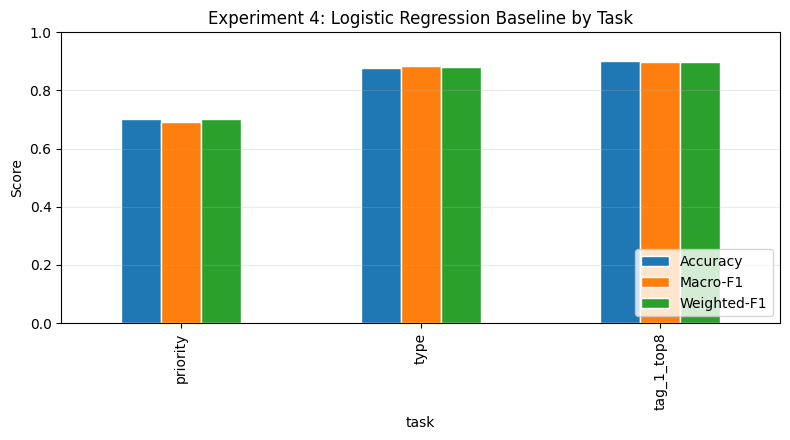

In [7]:
metrics = ['Accuracy', 'Macro-F1', 'Weighted-F1']
plot_data = summary.set_index('task')[metrics]

fig, ax = plt.subplots(figsize=(8, 4.5))
plot_data.plot(kind='bar', ax=ax, edgecolor='white')
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score')
ax.set_title('Experiment 4: Logistic Regression Baseline by Task')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(OUT_DIR / 'Experiment_4_large_baseline_summary.png', dpi=150)
plt.show()

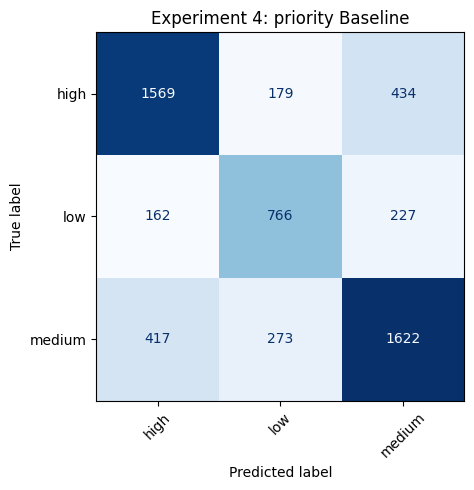

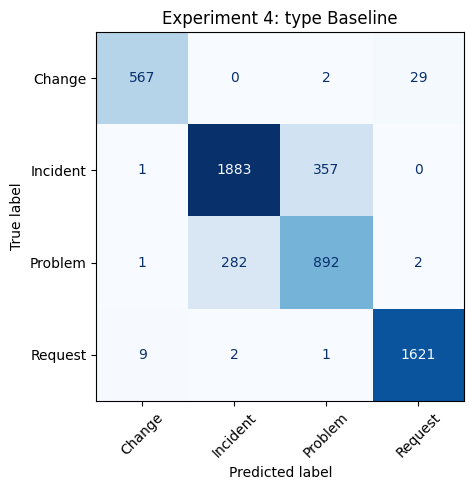

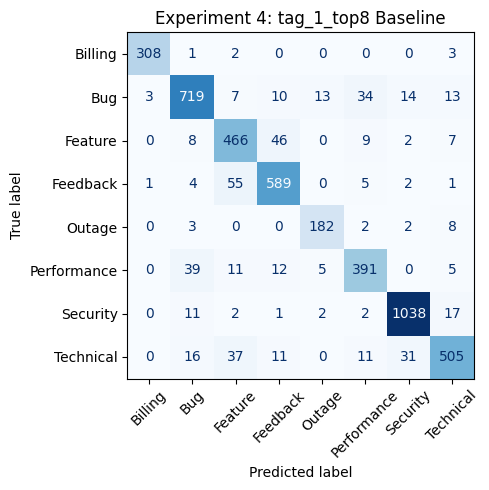

In [8]:
for task in tasks:
    pred_df = pd.read_csv(OUT_DIR / f'Experiment_4_{task}_baseline_predictions.csv')
    labels = sorted(pred_df['label'].unique())

    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(
        pred_df['label'],
        pred_df['pred_label'],
        labels=labels,
        cmap='Blues',
        colorbar=False,
        ax=ax,
    )
    ax.set_title(f'Experiment 4: {task} Baseline')
    ax.tick_params(axis='x', rotation=45)
    fig.tight_layout()
    fig.savefig(OUT_DIR / f'Experiment_4_{task}_baseline_confusion.png', dpi=150)
    plt.show()

## Conclusion

The lexical baseline is already strong, suggesting that many labels are tied to explicit ticket wording. Experiment 5 tests whether a margin-based linear classifier improves it.